> **Branch:** `feature/stage4-eda`  
> **Author:** Adithyan  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


---
# STAGE 4 — Exploratory Data Analysis (EDA)
**Author: Adithyan**  
**Branch: feature/stage4-eda**

---

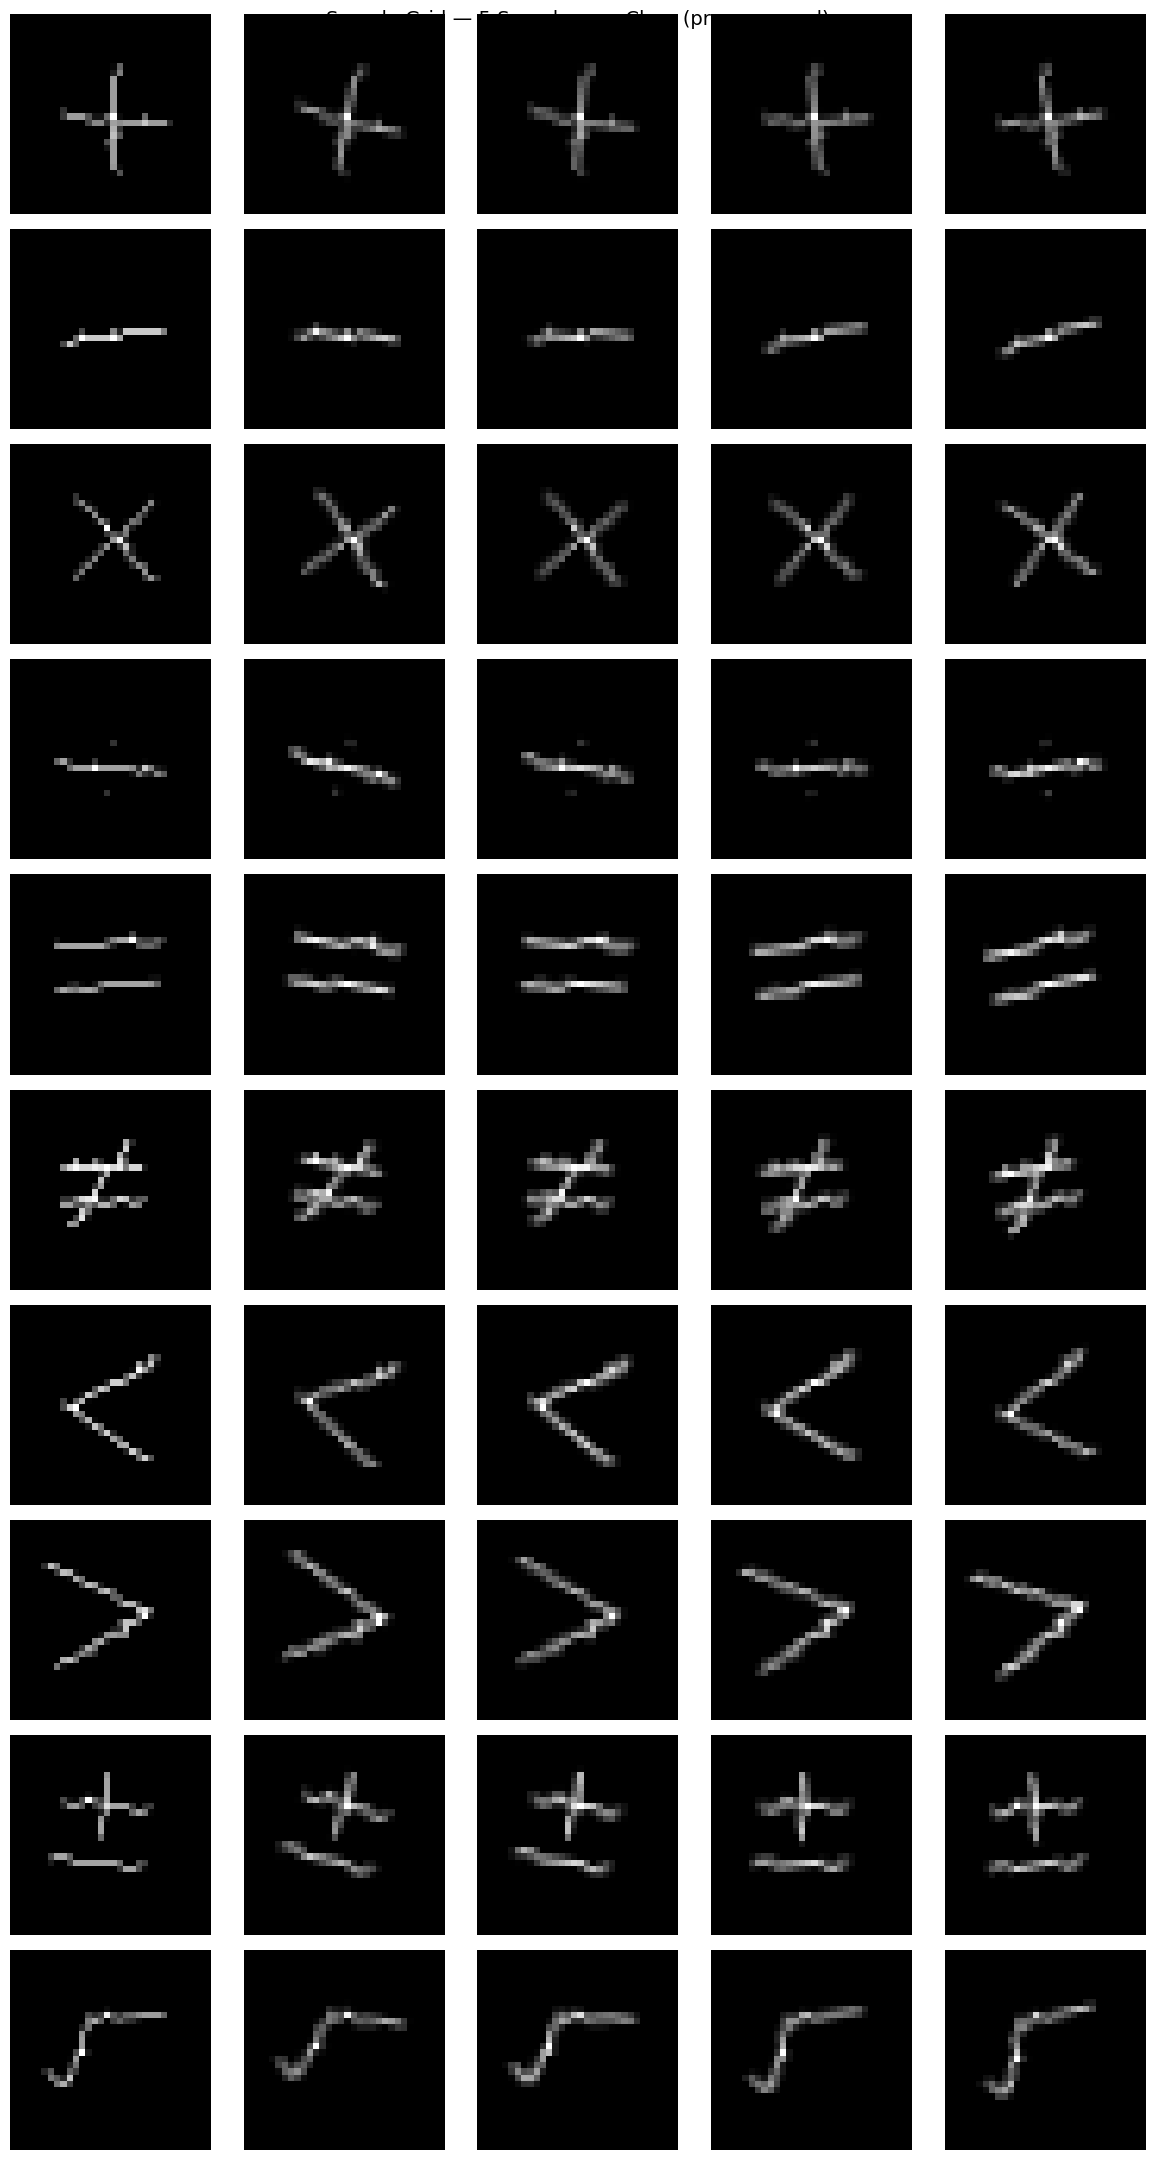

In [19]:
# ============================================================
# STAGE 4 — EXPLORATORY DATA ANALYSIS
# Author: Adithyan
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

symbols = list(class_mapping.values())
idx_to_symbol = {v: k for k, v in label_map.items()}

# ── 4.1 Sample Grid: 5 samples per class ──────────────────
fig, axes = plt.subplots(10, 5, figsize=(12, 22))
fig.suptitle('Sample Grid — 5 Samples per Class (preprocessed)', fontsize=14)

for class_idx, symbol in enumerate(symbols):
    class_samples = X[y == class_idx][:5]
    for col, sample in enumerate(class_samples):
        ax = axes[class_idx][col]
        ax.imshow(sample.reshape(32, 32), cmap='gray')
        if col == 0:
            ax.set_ylabel(symbol, fontsize=14, rotation=0, labelpad=20)
        ax.axis('off')

plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150)
plt.show()

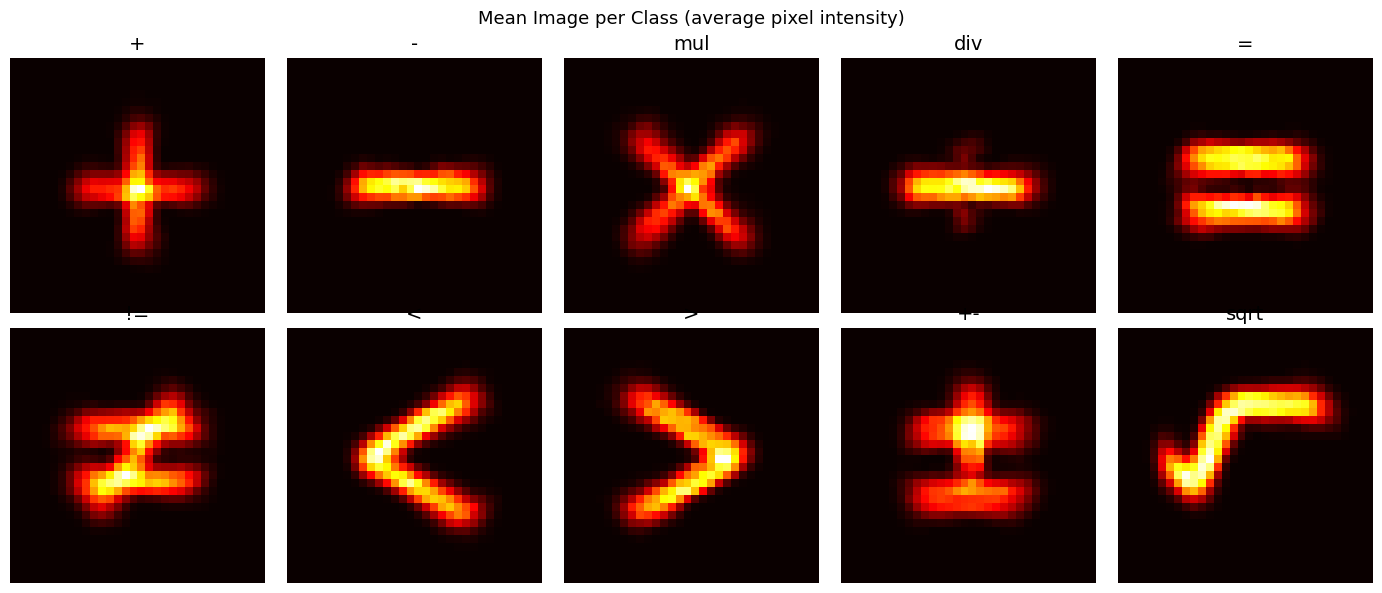

In [20]:
# ── 4.2 Mean Image per Class ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Mean Image per Class (average pixel intensity)', fontsize=13)

for ax, (class_idx, symbol) in zip(axes.flatten(),
                                    enumerate(symbols)):
    class_samples = X[y == class_idx]
    mean_img = class_samples.mean(axis=0).reshape(32, 32)
    ax.imshow(mean_img, cmap='hot')
    ax.set_title(symbol, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('eda_mean_images.png', dpi=150)
plt.show()

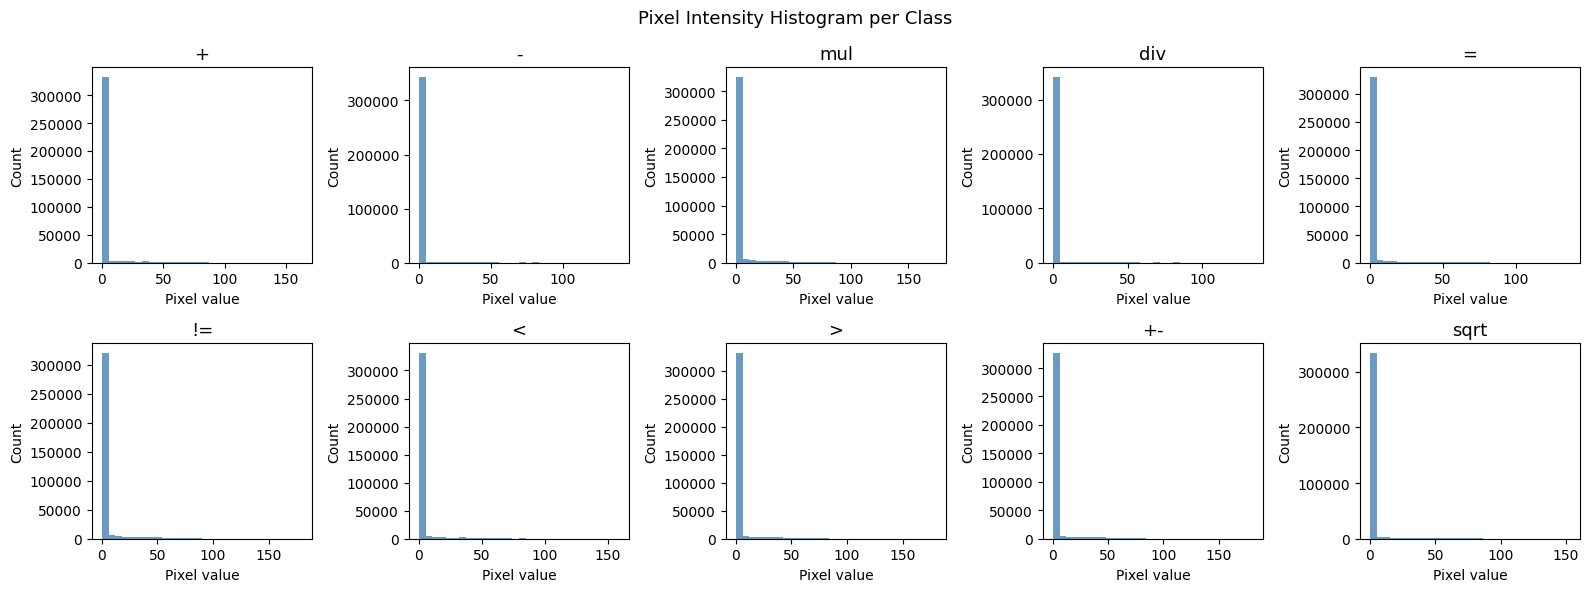

In [21]:
# ── 4.3 Pixel Intensity Distribution per Class ────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Pixel Intensity Histogram per Class', fontsize=13)

for ax, (class_idx, symbol) in zip(axes.flatten(),
                                    enumerate(symbols)):
    class_samples = X[y == class_idx]
    ax.hist(class_samples.flatten(), bins=30,
            color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(symbol, fontsize=13)
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=150)
plt.show()

In [22]:
# ── 4.4 Identify Visually Confusable Pairs ────────────────
print("Visually confusable symbol pairs (based on structural similarity):")
confusable_pairs = [
    ('+', '÷', 'Both have a vertical stroke — differ only in horizontal bar position'),
    ('<', '>', 'Mirror images — easy to confuse if strokes are unclear'),
    ('=', '≠', 'Nearly identical — ≠ adds a diagonal slash through ='),
    ('+', '±', '± is an extension of + with a minus bar below'),
    ('−', '÷', 'Division sign contains a horizontal bar like minus'),
]

for s1, s2, reason in confusable_pairs:
    print(f"  {s1} vs {s2}: {reason}")

print("\n✅ Stage 4 EDA Complete")

Visually confusable symbol pairs (based on structural similarity):
  + vs ÷: Both have a vertical stroke — differ only in horizontal bar position
  < vs >: Mirror images — easy to confuse if strokes are unclear
  = vs ≠: Nearly identical — ≠ adds a diagonal slash through =
  + vs ±: ± is an extension of + with a minus bar below
  − vs ÷: Division sign contains a horizontal bar like minus

✅ Stage 4 EDA Complete
